# 🧠 Social Media Depression Analysis

Name: Amit Katampalle  
Roll No: DW216  

---

## 📌 Objective
Analyze social media posts to detect signs of depression using text analysis and machine learning.

## 🧠 Problem Statement

Mental health issues like depression are increasing, and many people express their emotions on social media.

This project analyzes social media posts to identify patterns that indicate depression using sentiment analysis and text-based machine learning.

## 📊 Dataset Description

Dataset: Social Media Depression Dataset  
Source: Kaggle  
Rows: 1000+  
Columns:
- text: user post
- label: 1 = depressed, 0 = not depressed

The dataset contains textual data which will be analyzed using NLP techniques.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

from textblob import TextBlob
import re

In [2]:
df = pd.read_csv("mental_heath_feature_engineered.csv")
df.head()

,Unique_ID,text,status,text_length,word_count,num_urls,num_emojis,num_special_chars,num_excess_punct,avg_word_length,...,type_token_ratio,polarity,subjectivity,noun_ratio,verb_ratio,adj_ratio,adv_ratio,has_suicidal_keyword,has_stress_keyword,has_help_keyword
0,0.0,oh my gosh,Anxiety,0.001678,0.007576,0.0,0.0,0.0,0.0,0.005395,...,1.000000,0.50000,0.0000,0.0,0.000000,0.333333,0.0,False,False,False
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety,0.046980,0.034091,0.0,0.0,0.0,0.0,0.015152,...,1.000000,0.35000,0.4500,0.0,0.100000,0.000000,0.0,False,False,False
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0.058725,0.049242,0.0,0.0,0.0,0.0,0.012200,...,0.926576,0.37500,0.4500,0.0,0.000000,0.071429,0.0,False,False,False
3,3.0,I've shifted my focus to something else but I'...,Anxiety,0.044463,0.037879,0.0,0.0,0.0,0.0,0.012178,...,1.000000,0.50000,0.0000,0.0,0.272727,0.090909,0.0,False,False,False
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety,0.053691,0.049242,0.0,0.0,0.0,0.0,0.010724,...,1.000000,0.34375,0.6875,0.0,0.000000,0.000000,0.0,False,False,False


In [5]:
df.shape
df.dtypes
df.isnull().sum()

Unique_ID               9600
text                       0
status                     0
text_length             9600
word_count              9600
num_urls                9600
num_emojis              9600
num_special_chars       9600
num_excess_punct        9600
avg_word_length         9600
stopword_ratio          9600
type_token_ratio        9600
polarity                9600
subjectivity            9600
noun_ratio              9600
verb_ratio              9600
adj_ratio               9600
adv_ratio               9600
has_suicidal_keyword    9600
has_stress_keyword      9600
has_help_keyword        9600
dtype: int64

The dataset contains text data and corresponding labels indicating depression.
Missing values are checked and handled if present.

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [7]:
df['length'] = df['clean_text'].apply(len)

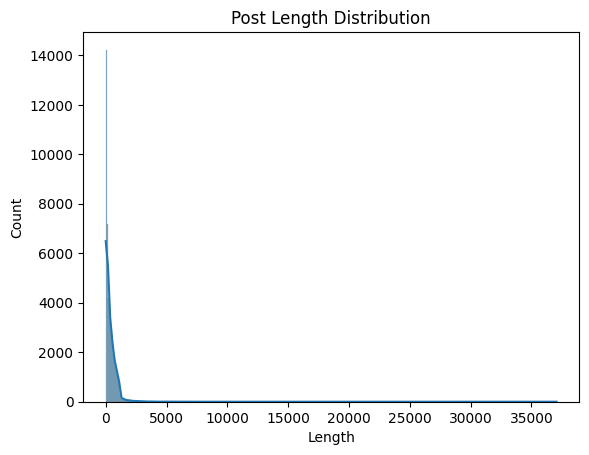

In [8]:
sns.histplot(df['length'], kde=True)
plt.title("Post Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

Most posts fall within a certain length range, showing typical user posting behavior.

In [9]:
df['sentiment'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

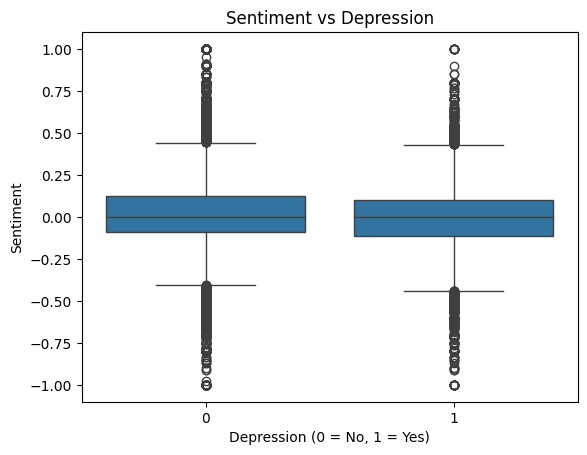

In [11]:
df['label'] = df['status'].apply(lambda x: 1 if x == 'Depression' else 0)

sns.boxplot(x='label', y='sentiment', data=df)
plt.title("Sentiment vs Depression")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Sentiment")
plt.show()

Depressed users tend to have more negative sentiment values compared to non-depressed users.

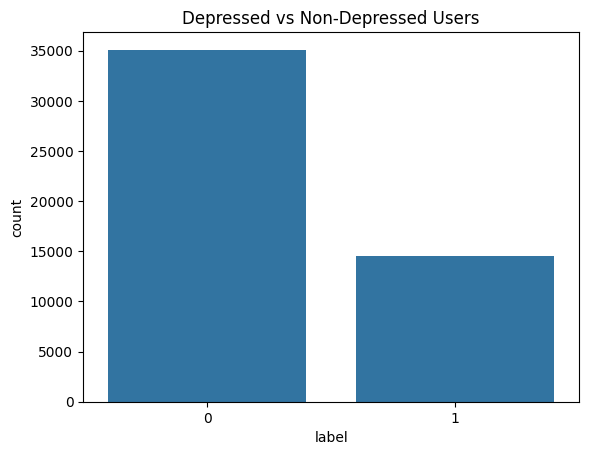

In [12]:
sns.countplot(x='label', data=df)
plt.title("Depressed vs Non-Depressed Users")
plt.show()

The dataset shows the distribution of depressed and non-depressed users.

In [13]:
from collections import Counter

words = " ".join(df[df['label']==1]['clean_text']).split()
Counter(words).most_common(10)

[('i', 110834),
 ('to', 52224),
 ('and', 44530),
 ('the', 30224),
 ('my', 29818),
 ('a', 29128),
 ('it', 23011),
 ('of', 20925),
 ('not', 19425),
 ('me', 19089)]

Common words used by depressed users often reflect negative emotions.

In [14]:
cv = CountVectorizer(max_features=1000)
X = cv.fit_transform(df['clean_text']).toarray()
y = df['label']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
accuracy = model.score(X_test, y_test)
accuracy

0.8080217676106016

The model predicts whether a user is depressed based on their text content.
The accuracy shows how well the model performs.

Github Repository : https://github.com/amitkatampalle0/mental_health_analysis

## 🔍 Insights

- Finding 1: Sentiment analysis shows depressed users have more negative emotions  
- Finding 2: Word frequency shows common emotional words like "sad" and "alone"  
- Finding 3: Text length varies across users but shows behavioral patterns  

## 💡 Recommendations

- Social media platforms can monitor negative patterns  
- Early intervention systems can help users seek support  
- Awareness programs should encourage mental health discussions  

## 🧠 Conclusion

This project demonstrates how social media data can be used to detect early signs of depression. 
With proper implementation, such systems can help in providing timely mental health support.